# Alzheimer's Disease Classification

Alzheimer's Disease classification using the AlzheimersDiseaseCNN model on the ADNI 
dataset, as described in the paper  "On the Design of Convolutional Neural Networks 
for Automatic Detection of Alzheimer's Disease" by Liu et al.
(https://arxiv.org/abs/1911.03740).

## Experimental Setup
Access to real ADNI data was obtained and 3182 MRI image files were downloaded.

This dataset consists of 675 patients, with the images split between the three 
diagnostic labels (MCI/CN/AD) as 1687/937/558. Note the class imbalance, which 
is addressed by using balanced_accuracy rather than the regular accuracy score. 
We have also employed weighted cross-entropy loss using computed class weights 
to attempt to offset the imbalance.

Training is partitioned at the patient level (70/15/15) to prevent scan-level 
leakage. Remaining training parameters are as follows:

    Optimizer:  SGD, lr=0.01, momentum=0.9, batch_size=4
    Epochs:     50 with early stopping (patience=10)
    Monitor:    balanced_accuracy (accounts for the class imbalance)

## Experiments
Three experiments are performed here, which parallel the hypotheses described by 
Liu et al., namely:

- Width Factor
- Age Encoding
- Batch vs Instance Normalization

#### Experiment 1: Width Factor
Tests the paper's central finding that wider networks outperform deeper ones.

- Compare model widths of 1, 4 and 8.

#### Experiment 2: Age Encoding
Tests the sinusoidal age encoding described by Liu et al. in Appendix A.

- Compare accuracy with and without age encoding.

#### Experiment 3: Batch vs Instance Normalization
Tests the effect of batch vs instance normalization on the model's accuracy.

- Compare model using batch normalization vs instance normalization.


### Extensions

The following extensions not covered in the paper:

#### Experiment 4: Additional Attributes

Test the effect of including an additional patient attribute to the model's input, 
specifically gender. We will compare the model's accuracy under each of the following 
scenarios:

- Only age
- Both age and gender

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from pyhealth.datasets import ADNIDataset, get_dataloader
from pyhealth.datasets.splitter import split_by_patient # New splitter
from pyhealth.models import AlzheimersDiseaseCNN
from pyhealth.tasks import AlzheimersDiseaseClassification
from pyhealth.trainer import Trainer

from matplotlib.ticker import ScalarFormatter
from sklearn.metrics import confusion_matrix
from torch.optim import SGD

### Initialize

In [2]:
# Initialization
BATCH_SIZE = 4
EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 0.01
MOMENTUM = 0.9
METRICS = ["balanced_accuracy", "accuracy", "f1_macro", "roc_auc_macro_ovr"]
MONITOR = "balanced_accuracy"
SEED = 99

# Path where the ADNI files are located
ADNI_ROOT = r"./adni_root"
CACHE_DIR = r"./cache"
print(f"ADNI Root: {ADNI_ROOT}")
print(f"Cache Directory: {CACHE_DIR}")

ADNI Root: ./adni_root
Cache Directory: ./cache


Define an experiment runner function:

In [3]:
def run_experiment(samples, train_ds, val_ds, test_ds, class_weights, model_kwargs, batch_size=BATCH_SIZE, exp_name="", device="cpu"):
    """Train and evaluate one model configuration.

    Args:
        train_ds (SampleDataset): Training dataset.
        val_ds (SampleDataset): Validation dataset.
        test_ds (SampleDataset): Test dataset.
        model_kwargs (Dict): Keyword arguments passed to AlzheimersDiseaseCNN.
        exp_name (str): Name for logging and checkpointing.
        device (str): Device to use for computations. Default is "cpu".

    Returns:
        Dict: Test scores for this configuration.
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"Config: {model_kwargs}")
    print(f"{'='*60}")

    # Create dataloaders
    train_loader = get_dataloader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = get_dataloader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = get_dataloader(test_ds, batch_size=batch_size, shuffle=False)

    # Pass SampleDataset to the model
    model = AlzheimersDiseaseCNN(dataset=samples, class_weights=class_weights, **model_kwargs)

    trainer = Trainer(
        model=model,
        metrics=METRICS,
        output_path="./output",
        exp_name=exp_name,
    )

    trainer.train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        test_dataloader=test_loader,
        epochs=EPOCHS,
        optimizer_class=SGD,
        optimizer_params={"lr": LEARNING_RATE, "momentum": MOMENTUM, "weight_decay": 1e-3},
        max_grad_norm=1.0,
        monitor=MONITOR,
        monitor_criterion="max",
        patience=PATIENCE,
        load_best_model_at_last=True,
    )

    # Retrieve scores
    scores = trainer.evaluate(test_loader)
    y_true, y_prob, _ = trainer.inference(test_loader)
    y_pred = np.argmax(y_prob, axis=1)

    print(f"Test scores: {scores}")

    scores["y_true"] = y_true
    scores["y_pred"] = y_pred

    return scores

In [4]:
# Instantiate base ADNI dataset
adni_dataset = ADNIDataset(root=ADNI_ROOT, cache_dir=CACHE_DIR, dev=False)
adni_dataset.stats()

# Set task and obtain samples
adni_task = AlzheimersDiseaseClassification()
sample_dataset = adni_dataset.set_task(adni_task)

# Split data by patient into train/val/test (70/15/15)
split_ratios = [0.7, 0.15, 0.15]
train_data, val_data, test_data = split_by_patient(sample_dataset, ratios=split_ratios, seed=SEED)

# Record all test data
test_results = {}

Initializing ADNI dataset from ./adni_root (dev mode: False)
Using provided cache_dir: cache\466bcd45-4d0c-51b2-8df9-f16f71654765
Found cached event dataframe: cache\466bcd45-4d0c-51b2-8df9-f16f71654765\global_event_df.parquet
Dataset: ADNI
Dev mode: False
Number of patients: 675
Number of events: 3182
Setting task AlzheimersDiseaseClassification for ADNI base dataset...
Task cache paths: task_df=cache\466bcd45-4d0c-51b2-8df9-f16f71654765\tasks\AlzheimersDiseaseClassification_06d5c45f-c9ae-5777-90a6-76fe4c381637\task_df.ld, samples=cache\466bcd45-4d0c-51b2-8df9-f16f71654765\tasks\AlzheimersDiseaseClassification_06d5c45f-c9ae-5777-90a6-76fe4c381637\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at cache\466bcd45-4d0c-51b2-8df9-f16f71654765\tasks\AlzheimersDiseaseClassification_06d5c45f-c9ae-5777-90a6-76fe4c381637\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.


In [5]:
from collections import Counter

# Calculate label distribution in given set
def label_distribution(ds, set_name):
    label_map={0: "CN", 1: "MCI", 2: "AD"}
    labels = [int(ds[i]["label"]) for i in range(len(ds))]
    counts = Counter(labels)
    total = len(labels)
    print(f"{set_name} Distribution ({total})")
    for idx, name in label_map.items():
        count = counts.get(idx, 0)
        print(f"  {name}: {count} ({count/total:.1%})")
    print("")

label_distribution(train_data, "Train")
label_distribution(val_data, "Val")
label_distribution(test_data, "Test")

Train Distribution (2195)
  CN: 600 (27.3%)
  MCI: 1200 (54.7%)
  AD: 395 (18.0%)

Val Distribution (473)
  CN: 161 (34.0%)
  MCI: 232 (49.0%)
  AD: 80 (16.9%)

Test Distribution (514)
  CN: 176 (34.2%)
  MCI: 255 (49.6%)
  AD: 83 (16.1%)



In [6]:
# Compute training class weights since the classes are very imbalanced
train_labels = [int(train_data[i]["label"]) for i in range(len(train_data))]
counts = Counter(train_labels)
total = len(train_labels)
class_weights = torch.tensor([
    total / counts[0],  # CN
    total / counts[1],  # MCI  
    total / counts[2],  # AD
], dtype=torch.float32)
class_weights = class_weights / class_weights.sum()
print(class_weights)

tensor([0.3312, 0.1656, 0.5031])


### Test 1: Width Factor

In their paper, Liu et al. compare model performance with varying widths and conclude that widening networks produces better classification performance up to a point. Liu et al. find that a width factor of 8 is optimal.

We will determine our optimum width factor by testing values of 1, 4 and 8.

In [7]:
print("Test 1: Width Factor")
test_results["Width"] = {}
for wf in [1, 4, 8]:
    name = f"Width {wf}"
    test_results["Width"][wf] = run_experiment(
        sample_dataset,
        train_data, val_data, test_data,
        class_weights=class_weights,
        model_kwargs={"width_factor": wf, "use_age": True, "norm_method": "instance"},
        exp_name=name,
        batch_size=BATCH_SIZE,
    )

Test 1: Width Factor

Experiment: Width 1
Config: {'width_factor': 1, 'use_age': True, 'norm_method': 'instance'}
AlzheimersDiseaseCNN(
  (block1): Sequential(
    (0): Conv3d(1, 4, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (1): InstanceNorm3d(4, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), dilation=(2, 2, 2))
    (1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(32, 64, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2), dilation=(2, 2, 2))
    (1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)


Epoch 0 / 50:   0%|          | 0/549 [00:00<?, ?it/s]

--- Train epoch-0, step-549 ---
loss: 1.7826


Evaluation: 100%|██████████| 119/119 [00:02<00:00, 43.72it/s]

--- Eval epoch-0, step-549 ---
balanced_accuracy: 0.3333
accuracy: 0.4905
f1_macro: 0.2194
roc_auc_macro_ovr: 0.5754
loss: 1.7891
New best balanced_accuracy score (0.3333) at epoch-0, step-549



...

--- Eval epoch-18, step-10431 ---
balanced_accuracy: 0.3851
accuracy: 0.4884
f1_macro: 0.3498
roc_auc_macro_ovr: 0.5776
loss: 1.0335
Early stopping at epoch-18, step-10431
Loaded best model



Evaluation: 100%|██████████| 129/129 [00:06<00:00, 20.14it/s]

--- Test ---
balanced_accuracy: 0.4061
accuracy: 0.4786
f1_macro: 0.3454
roc_auc_macro_ovr: 0.5509
loss: 1.0708



Evaluation: 100%|██████████| 129/129 [00:06<00:00, 20.65it/s]

Test scores: {'balanced_accuracy': 0.40606060606060607, 'accuracy': 0.4785992217898833, 'f1_macro': 0.34539847722662403, 'roc_auc_macro_ovr': 0.5509393380434227, 'loss': 1.0708053434310958}


In [8]:
best_wf = max(
    test_results["Width"],
    key=lambda k: test_results["Width"][k].get("balanced_accuracy", 0)
)
best_wf_value = int(best_wf)
print(f"\nBest width_factor: {best_wf_value}")


Best width_factor: 1


In [9]:
for config, results in test_results["Width"].items():
    print(f"Width: {config}")
    for metric, score in results.items():
        if isinstance(score, (int, float)):
            print(f"  {metric}: {score:.2}")
    print("")

Width: 1
  balanced_accuracy: 0.5
  accuracy: 0.55
  f1_macro: 0.5
  roc_auc_macro_ovr: 0.7
  loss: 2.9

Width: 4
  balanced_accuracy: 0.4
  accuracy: 0.49
  f1_macro: 0.35
  roc_auc_macro_ovr: 0.59
  loss: 1.0

Width: 8
  balanced_accuracy: 0.41
  accuracy: 0.48
  f1_macro: 0.35
  roc_auc_macro_ovr: 0.55
  loss: 1.1



In [10]:
print(f"The best width factor is {best_wf_value}\n")
for metric, score in test_results["Width"][best_wf].items():
    if isinstance(score, (int, float)):
        print(f"  {metric:<{22}}{score:.2f}")

The best width factor is 1

  balanced_accuracy     0.50
  accuracy              0.55
  f1_macro              0.50
  roc_auc_macro_ovr     0.70
  loss                  2.90


### Test 2: Age Encoding
Liu et al. test the inclusion of age as a means of providing the model with context with regards to aging brain structure, which may otherwise confuse the classification.

We will compare the effectiveness of the model with and without incorporating age data.

For this experiment we will use a fixed width factor of 4.

In [11]:
print("Test 2: Age encoding")
test_results["Age"] = {}
for use_age in [False, True]:
    name = f"Age={use_age}"
    test_results["Age"][use_age] = run_experiment(
        sample_dataset,
        train_data, val_data, test_data,
        class_weights=class_weights,
        model_kwargs={"width_factor": 4, "use_age": use_age},
        exp_name=name,
        batch_size=4,
    )

Test 2: Age encoding

Experiment: Age=False
Config: {'width_factor': 4, 'use_age': False}
AlzheimersDiseaseCNN(
  (block1): Sequential(
    (0): Conv3d(1, 16, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(16, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), dilation=(2, 2, 2))
    (1): InstanceNorm3d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2), dilation=(2, 2, 2))
    (1): InstanceNorm3d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool

Epoch 0 / 50:   0%|          | 0/549 [00:00<?, ?it/s]

--- Train epoch-0, step-549 ---
loss: 1.6319


Evaluation: 100%|██████████| 119/119 [00:03<00:00, 37.73it/s]

--- Eval epoch-0, step-549 ---
balanced_accuracy: 0.3333
accuracy: 0.4905
f1_macro: 0.2194
roc_auc_macro_ovr: 0.4836
loss: 1.5435
New best balanced_accuracy score (0.3333) at epoch-0, step-549


...

--- Eval epoch-26, step-14823 ---
balanced_accuracy: 0.4458
accuracy: 0.5412
f1_macro: 0.4487
roc_auc_macro_ovr: 0.6960
loss: 3.4910
Early stopping at epoch-26, step-14823
Loaded best model



Evaluation: 100%|██████████| 129/129 [00:03<00:00, 36.91it/s]

--- Test ---
balanced_accuracy: 0.4224
accuracy: 0.5195
f1_macro: 0.3776
roc_auc_macro_ovr: 0.6644
loss: 2.0024



Evaluation: 100%|██████████| 129/129 [00:03<00:00, 37.58it/s]

Test scores: {'balanced_accuracy': 0.422363339275104, 'accuracy': 0.519455252918288, 'f1_macro': 0.3776172198389403, 'roc_auc_macro_ovr': 0.6644131362741549, 'loss': 2.002371204980337}


In [12]:
# Compute and display results
for use_age, results in test_results["Age"].items():
    print(f"{'With' if use_age else 'Without'} Age:")
    for metric, score in results.items():
        if isinstance(score, (int, float)):
            print(f"  {metric:<{22}}{score:.2f}")
    print("")

Without Age:
  balanced_accuracy     0.33
  accuracy              0.50
  f1_macro              0.22
  roc_auc_macro_ovr     0.56
  loss                  1.52

With Age:
  balanced_accuracy     0.42
  accuracy              0.52
  f1_macro              0.38
  roc_auc_macro_ovr     0.66
  loss                  2.00



## Test 3: Batch vs Instance Normalization
Liu et al. compare model accuracy using batch normalization and instance normalization, and find that instance normalization outperforms batch normalization in all of their experiments.

We will compare model performance using a fixed width of 4.

In [13]:
print("Test 3: Batch vs Instance Normalization")
test_results["Norm"] = {}
test_params = { "instance": 4, "batch": 8 }
for norm_method, batch_size in test_params.items():
    test_results["Norm"][norm_method] = run_experiment(
        sample_dataset,
        train_data, val_data, test_data,
        class_weights=class_weights,
        model_kwargs={"norm_method": norm_method},
        exp_name=norm_method,
        batch_size=batch_size,
    )

Test 3: Batch vs Instance Normalization

Experiment: instance
Config: {'norm_method': 'instance'}
AlzheimersDiseaseCNN(
  (block1): Sequential(
    (0): Conv3d(1, 16, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(16, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), dilation=(2, 2, 2))
    (1): InstanceNorm3d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2), dilation=(2, 2, 2))
    (1): InstanceNorm3d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3):

Epoch 0 / 50:   0%|          | 0/549 [00:00<?, ?it/s]

--- Train epoch-0, step-549 ---
loss: 1.5215


Evaluation: 100%|██████████| 119/119 [00:03<00:00, 37.78it/s]

--- Eval epoch-0, step-549 ---
balanced_accuracy: 0.3333
accuracy: 0.4905
f1_macro: 0.2194
roc_auc_macro_ovr: 0.5649
loss: 1.0617
New best balanced_accuracy score (0.3333) at epoch-0, step-549


...

--- Eval epoch-28, step-7975 ---
balanced_accuracy: 0.4333
accuracy: 0.5011
f1_macro: 0.4390
roc_auc_macro_ovr: 0.6310
loss: 3.8123
Early stopping at epoch-28, step-7975
Loaded best model



Evaluation: 100%|██████████| 65/65 [00:03<00:00, 20.75it/s]

--- Test ---
balanced_accuracy: 0.4700
accuracy: 0.4300
f1_macro: 0.4229
roc_auc_macro_ovr: 0.6297
loss: 1.5059



Evaluation: 100%|██████████| 65/65 [00:03<00:00, 20.58it/s]

Test scores: {'balanced_accuracy': 0.4700499860404183, 'accuracy': 0.42996108949416345, 'f1_macro': 0.4228531369534196, 'roc_auc_macro_ovr': 0.629730177899849, 'loss': 1.505904375589811}


In [14]:
# Compute and display results
for key, results in test_results["Norm"].items():
    print(f"Normalization method: {key}")
    for metric, score in results.items():
        if isinstance(score, (int, float)):
            print(f"  {metric:<{22}}{score:.2f}")
    print("")

Normalization method: instance
  balanced_accuracy     0.48
  accuracy              0.46
  f1_macro              0.46
  roc_auc_macro_ovr     0.64
  loss                  2.19

Normalization method: batch
  balanced_accuracy     0.47
  accuracy              0.43
  f1_macro              0.42
  roc_auc_macro_ovr     0.63
  loss                  1.51



# Extensions

Extending the findings presented by Liu et al. by exploring additional experiments.

### Test 4: Additional Patient Attributes

In their paper, Liu et al. add age as an additional data point to provide the model with greater context. According to the UK Alzheimer's Society, Alzheimer's Disease is more common in women although the correlation is not yet understood [(link)](https://www.alzheimers.org.uk/blog/why-dementia-different-women).

Therefore, we propose adding gender in addition to age, to explore the effect on model accuracy.

In [15]:
print("Test 4: Gender encoding")
test_results["Gender"] = {}
for use_gender in [False, True]:
    name = f"use_gender={use_gender}"
    test_results["Gender"][use_gender] = run_experiment(
        sample_dataset,
        train_data, val_data, test_data,
        class_weights=class_weights,
        model_kwargs={"width_factor": 4, "use_age": True, "use_gender": use_gender},
        exp_name=name,
        batch_size=4,
    )

Test 4: Gender encoding

Experiment: use_gender=False
Config: {'width_factor': 4, 'use_age': True, 'use_gender': False}
AlzheimersDiseaseCNN(
  (block1): Sequential(
    (0): Conv3d(1, 16, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(16, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), dilation=(2, 2, 2))
    (1): InstanceNorm3d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2), dilation=(2, 2, 2))
    (1): InstanceNorm3d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(

Epoch 0 / 50:   0%|          | 0/549 [00:00<?, ?it/s]

--- Train epoch-0, step-549 ---
loss: 1.7271


Evaluation: 100%|██████████| 119/119 [00:03<00:00, 36.83it/s]

--- Eval epoch-0, step-549 ---
balanced_accuracy: 0.3333
accuracy: 0.4905
f1_macro: 0.2194
roc_auc_macro_ovr: 0.5383
loss: 1.3440
New best balanced_accuracy score (0.3333) at epoch-0, step-549


...

--- Eval epoch-25, step-14274 ---
balanced_accuracy: 0.4887
accuracy: 0.5941
f1_macro: 0.4903
roc_auc_macro_ovr: 0.7296
loss: 4.1922
Early stopping at epoch-25, step-14274
Loaded best model



Evaluation: 100%|██████████| 129/129 [00:04<00:00, 31.63it/s]

--- Test ---
balanced_accuracy: 0.4668
accuracy: 0.5486
f1_macro: 0.4622
roc_auc_macro_ovr: 0.7022
loss: 2.0472



Evaluation: 100%|██████████| 129/129 [00:03<00:00, 32.93it/s]

Test scores: {'balanced_accuracy': 0.4668499309179677, 'accuracy': 0.5486381322957199, 'f1_macro': 0.46224884742116906, 'roc_auc_macro_ovr': 0.7021534664646426, 'loss': 2.0472309724135593}


In [16]:
# Compute and display results
for key, results in test_results["Gender"].items():
    print(f"Use Gender: {key}")
    for metric, score in results.items():
        if isinstance(score, (int, float)):
            print(f"  {metric:<{22}}{score:.2f}")
    print("")

Use Gender: False
  balanced_accuracy     0.41
  accuracy              0.47
  f1_macro              0.33
  roc_auc_macro_ovr     0.59
  loss                  1.09

Use Gender: True
  balanced_accuracy     0.47
  accuracy              0.55
  f1_macro              0.46
  roc_auc_macro_ovr     0.70
  loss                  2.05



### Test 5: Best Parameters

Exploring whether the best parameters determined in this test environment can replicate the level of accuracy demonstrated by Liu et al.

In [20]:
# Best parameter test
print("Test 5: Best parameters")
test_results["Best"] = {}
name = f"best_params"
for norm_method in ["batch", "instance"]:
    test_results["Best"][norm_method] = run_experiment(
        sample_dataset,
        train_data, val_data, test_data,
        class_weights=class_weights,
        model_kwargs={"width_factor": 1, "use_age": True, "use_gender": True, "norm_method": norm_method},
        exp_name=name,
        batch_size=4,
    )

Test 5: Best parameters

Experiment: best_params
Config: {'width_factor': 1, 'use_age': True, 'use_gender': True, 'norm_method': 'batch'}
AlzheimersDiseaseCNN(
  (block1): Sequential(
    (0): Conv3d(1, 4, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (1): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), dilation=(2, 2, 2))
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(32, 64, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2), dilation=(2, 2, 2))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inpla

Epoch 0 / 50:   0%|          | 0/549 [00:00<?, ?it/s]

--- Train epoch-0, step-549 ---
loss: 2.7455


Evaluation: 100%|██████████| 119/119 [00:02<00:00, 55.36it/s]

--- Eval epoch-0, step-549 ---
balanced_accuracy: 0.4162
accuracy: 0.4693
f1_macro: 0.4205
roc_auc_macro_ovr: 0.6116
loss: 1.8078
New best balanced_accuracy score (0.4162) at epoch-0, step-549



...

--- Eval epoch-27, step-15372 ---
balanced_accuracy: 0.4705
accuracy: 0.5708
f1_macro: 0.4768
roc_auc_macro_ovr: 0.7175
loss: 4.2230
Early stopping at epoch-27, step-15372
Loaded best model



Evaluation: 100%|██████████| 129/129 [00:02<00:00, 53.19it/s]

--- Test ---
balanced_accuracy: 0.5512
accuracy: 0.5370
f1_macro: 0.5253
roc_auc_macro_ovr: 0.7315
loss: 2.7000



Evaluation: 100%|██████████| 129/129 [00:02<00:00, 55.43it/s]

Test scores: {'balanced_accuracy': 0.5512455347235644, 'accuracy': 0.5369649805447471, 'f1_macro': 0.5253467041419434, 'roc_auc_macro_ovr': 0.7315290487151698, 'loss': 2.7000376726527295}


In [21]:
# Compute and display results
for key, results in test_results["Best"].items():
    print(f"Best: {key}")
    for metric, score in results.items():
        if isinstance(score, (int, float)):
            print(f"  {metric:<{22}}{score:.2f}")
    print("")

Best: batch
  balanced_accuracy     0.52
  accuracy              0.52
  f1_macro              0.50
  roc_auc_macro_ovr     0.72
  loss                  3.27

Best: instance
  balanced_accuracy     0.55
  accuracy              0.54
  f1_macro              0.53
  roc_auc_macro_ovr     0.73
  loss                  2.70



## Outcomes
Comparisons of this notebook's outcomes vs Liu et al.

In [22]:
# Assemble data from experiments
results_rows = []
for test_name, configurations in test_results.items():
    for metric, scores in configurations.items():
        test_row = {"Experiment": f"{test_name} ({metric})"}
        test_row.update(scores)
        results_rows.append(test_row)
results_df = pd.DataFrame(results_rows)
results_df = results_df.set_index("Experiment")

# Rename columns
column_map = {
    "accuracy": "Accuracy (%)",
    "balanced_accuracy": "Balanced Acc (%)",
    "f1_macro": "F1-Macro",
    "roc_auc_macro_ovr": "Macro-AUC",
    "loss": "Loss"
}
results_df = results_df.rename(columns=column_map)

# Rename experiments
experiment_map = {
    "Normalization (instance)": "Norm (Instance)",
    "Normalization (batch)": "Norm (Batch)",
    "Gender (False)": "Only Age",
    "Gender (True)": "Age + Gender"
}
results_df = results_df.rename(index=experiment_map)

# Convert percentage columns
pct_cols = ["Accuracy (%)", "Balanced Acc (%)"]
results_df[pct_cols] = results_df[pct_cols] * 100
results_df.round(2)

# Display table
display_columns = ["Balanced Acc (%)", "Accuracy (%)", "F1-Macro", "Macro-AUC", "Loss"]
results_df[display_columns].round(2)

,Balanced Acc (%),Accuracy (%),F1-Macro,Macro-AUC,Loss
Experiment,,,,,
Width (1),50.43,54.86,0.50,0.70,2.90
Width (4),40.25,48.64,0.35,0.59,1.04
Width (8),40.61,47.86,0.35,0.55,1.07
Age (False),33.33,49.61,0.22,0.56,1.52
Age (True),42.24,51.95,0.38,0.66,2.00
Norm (instance),48.27,46.50,0.46,0.64,2.19
Norm (batch),47.00,43.00,0.42,0.63,1.51
Only Age,41.15,46.69,0.33,0.59,1.09
Age + Gender,46.68,54.86,0.46,0.70,2.05


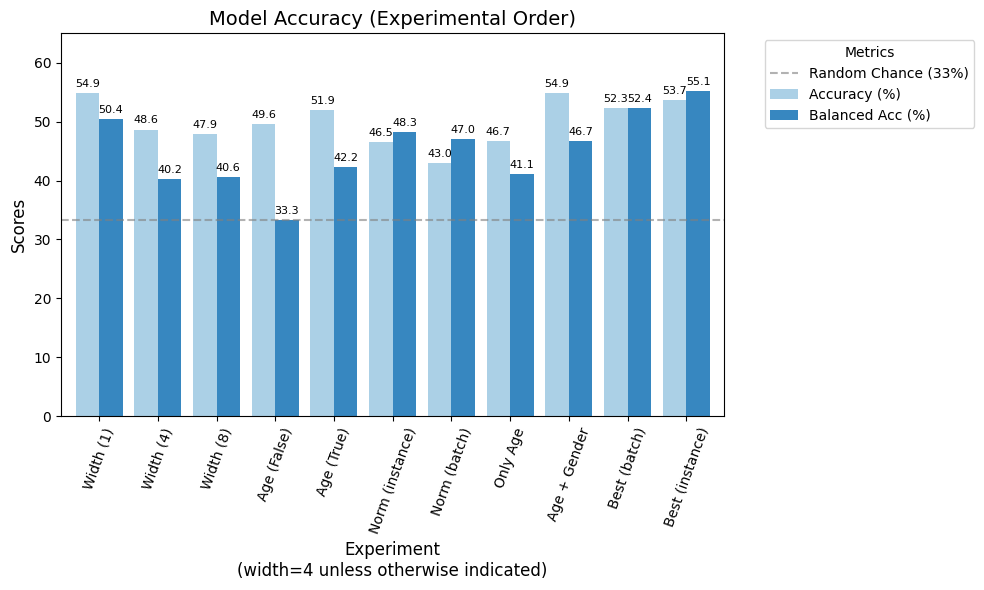

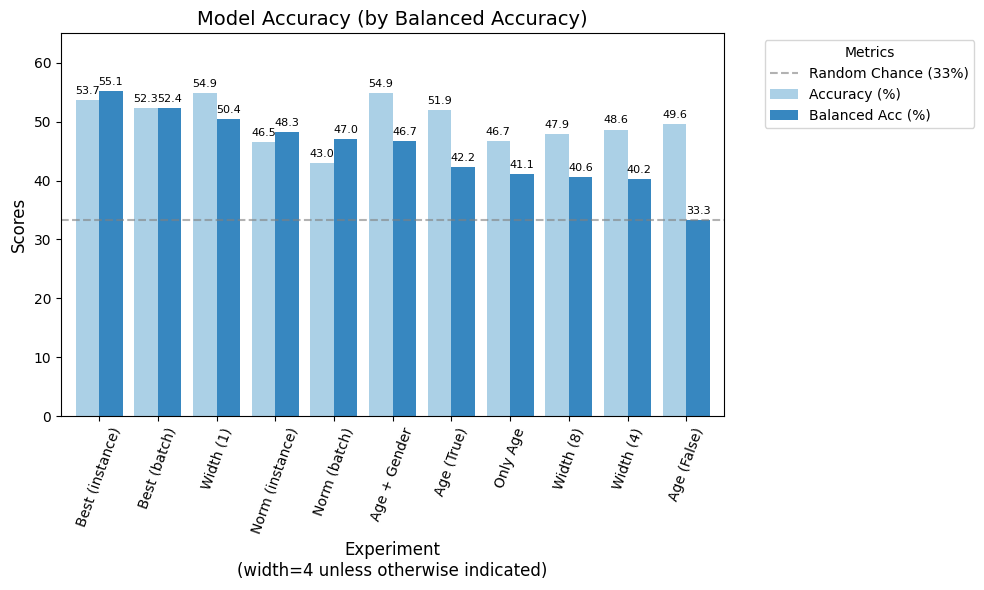

In [30]:
# Function to display model accuracy
def plot_model_accuracy(df, title):
    ax = df[["Accuracy (%)", "Balanced Acc (%)"]].plot.bar(
        rot=70,
        figsize=(10, 6),
        width=0.8,
        color=sns.color_palette("Blues", 2)
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Experiment\n(width=4 unless otherwise indicated)", fontsize=12)
    ax.set_ylabel("Scores", fontsize=12)
    ax.set_ylim(0, 65)
    ax.axhline(33.3, color='gray', linestyle='--', alpha=0.6, label='Random Chance (33%)')
    ax.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

# Display results in experimental order
plot_model_accuracy(results_df, "Model Accuracy (Experimental Order)")

# Display results sorted by balanced accuracy
sorted_results_df = results_df.sort_values(by="Balanced Acc (%)", ascending=False)
plot_model_accuracy(sorted_results_df, "Model Accuracy (by Balanced Accuracy)")

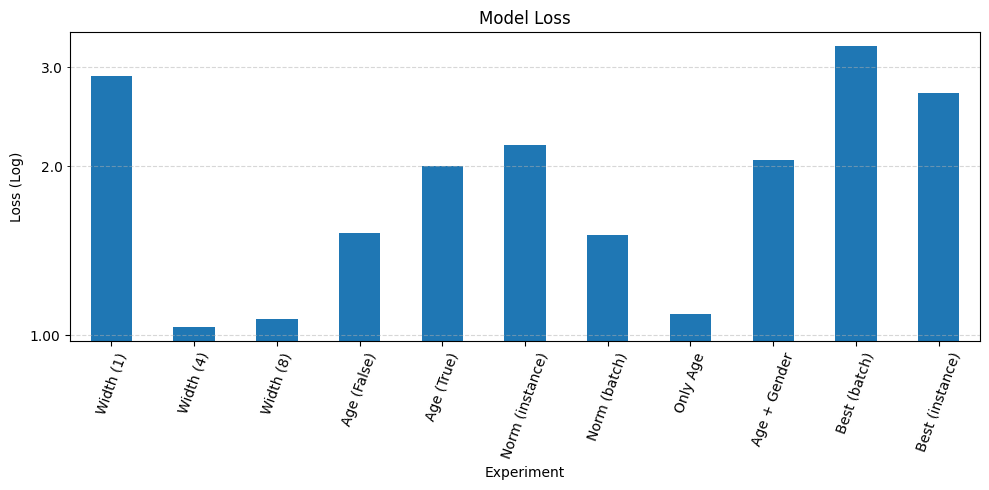

In [31]:
# Plot final loss
ax = results_df["Loss"].plot.bar(figsize=(10, 5), rot=70)

ax.set_yscale('log')
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(formatter)

ax.set_title("Model Loss")
ax.set_xlabel("Experiment")
ax.set_ylabel("Loss (Log)")
ax.grid(axis='y', which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Confusion Matrix:
[[103  52  21]
 [ 72 125  58]
 [  7  28  48]]


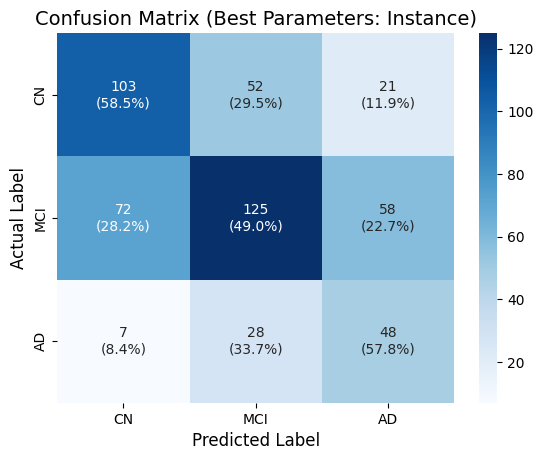

In [34]:
# Define labels and true/pred data
labels = ["CN", "MCI", "AD"]
y_true = test_results["Best"]["instance"]["y_true"]
y_pred = test_results["Best"]["instance"]["y_pred"]

# Generate matrix data
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

print("Confusion Matrix:")
print(cm)

# Add percentage annotations
annotations = (np.asarray([f"{count}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_pct.flatten())])).reshape(3, 3)

# Display confusion matrix
sns.heatmap(cm, annot=annotations, fmt="", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title(f"Confusion Matrix (Best Parameters: Instance)", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.show()